In [22]:
%%capture
#@title Imports (change based on file location)
# Need to change this based on model location in your system
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from torch.optim.lr_scheduler import ReduceLROnPlateau

import unet_model_class

In [24]:
MODEL_LOCATION = "/Users/joshuascheel/duckweed/best_model_0707.pt"

In [25]:
#@title Load Model Function
def load_model(checkpoint_path, model, optimizer=None):
    checkpoint = torch.load(checkpoint_path, map_location=torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimizer:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print(f"Loaded model from epoch {checkpoint['epoch']} with best_val_dice = {checkpoint['best_val_dice']:.4f}")
    return model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = unet_model_class.UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

model = load_model(MODEL_LOCATION, model, optimizer)


Loaded model from epoch 470 with best_val_dice = 0.8720


In [19]:
# Update path
IMAGE_PATH = "/Users/joshuascheel/duckweed/new_img_81 copy.png"

In [47]:
import torch
import numpy

print("Torch:", torch.__version__)
print("Numpy:", numpy.__version__)
print("Numpy path:", numpy.__file__)

Torch: 2.7.1
Numpy: 2.3.2
Numpy path: /Users/joshuascheel/duckweed/.venv/lib/python3.13/site-packages/numpy/__init__.py


In [46]:
!pip uninstall numpy -y
!pip install numpy --no-cache-dir

Found existing installation: numpy 2.2.6
Uninstalling numpy-2.2.6:
  Successfully uninstalled numpy-2.2.6
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 17.4 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.2 which is incompatible.


In [36]:
#@title Analyze Single Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import cv2 as cv2
from torchvision import transforms
from skimage import measure
from skimage.measure import regionprops_table
from skimage.color import label2rgb
from skimage.transform import resize
from matplotlib import gridspec
def analyze_single_image(frame, model, device='cuda'):

    model.eval()

    original_shape = frame.shape[:2]
    #original_shape = frame.size[::-1]
    input_size = (256, 256)

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize(input_size),
    ])
    #transform = transforms.Compose([
    #    transforms.Resize(input_size),
    #    transforms.ToTensor(),
    #])
    input_tensor = transform(frame).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred_mask = torch.sigmoid(output).squeeze().cpu().numpy()

    binary_mask_small = (pred_mask > 0.5).astype(np.uint8)
    binary_mask = resize(binary_mask_small, original_shape, preserve_range=True)
    binary_mask = (binary_mask > 0.5).astype(np.uint8)

    labeled_mask = measure.label(binary_mask)

    props = regionprops_table(
        labeled_mask,
        properties=['label', 'area', 'perimeter','major_axis_length', 'bbox', 'centroid']
    )

    # Create combined figure with gridspec (no space)
    fig = plt.figure(figsize=(frame.shape[1] * 2 / 100, frame.shape[0] / 100), dpi=100)
    gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0, hspace=0)

    ax1 = plt.subplot(gs[0])
    ax2 = plt.subplot(gs[1])

    ax1.imshow(frame)
    ax1.set_title("Original", fontsize=10)
    ax1.axis('off')

    overlay = label2rgb(labeled_mask, image=frame, bg_label=0)
    ax2.imshow(overlay)
    ax2.set_title("Predicted Mask", fontsize=10)
    ax2.axis('off')

    for region in measure.regionprops(labeled_mask):
        minr, minc, maxr, maxc = region.bbox
        cy, cx = region.centroid
        ax2.plot(
            [minc, maxc, maxc, minc, minc],
            [minr, minr, maxr, maxr, minr],
            color='red', linewidth=1.2
        )
        ax2.text(
            cx, cy, str(region.label),
            color='yellow', fontsize=6, ha='center', va='center',
            bbox=dict(facecolor='black', alpha=0.4, lw=0, pad=1)
        )

    plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)
    plt.show()

    return props

frame = cv2.imread(IMAGE_PATH)
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

region_info = analyze_single_image(frame_rgb, model)

#frame_pil = Image.fromarray(frame_rgb)
#region_info = analyze_single_image(frame_pil, model)

df = pd.DataFrame(region_info)
df['area'] = df['area'] * 0.00111
df['perimeter'] = df['perimeter'] * 0.03333
df['major_axis_length'] = df['major_axis_length'] * 0.03333
print('Area = mm^2 | Perimeter & Axis length = mm | Rest = pixels')
print(df)

RuntimeError: Numpy is not available

In [37]:
VIDEO_PATH = "/content/drive/MyDrive/Colab Notebooks/content/duckweed_25_0504_multiple.avi"
OUTPUT_PATH = "/content/drive/MyDrive/Colab Notebooks/content/test_output_vid.avi"

In [40]:
#@title Install btrack if not installed

!pip install btrack

  Using cached requests-2.32.4-py3-none-any.whl.metadata (4.9 kB)
  Using cached charset_normalizer-3.4.2-cp313-cp313-macosx_10_13_universal2.whl.metadata (35 kB)
  Using cached idna-3.10-py3-none-any.whl.metadata (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 21.5 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 18.4 MB/s eta 0:00:00
Using cached requests-2.32.4-py3-none-any.whl (64 kB)
Using cached charset_normalizer-3.4.2-cp313-cp313-macosx_10_13_universal2.whl (199 kB)
Using cached idna-3.10-py3-none-any.whl (70 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [btrack]10/11 [btrack]s]ormalizer]


In [ ]:
from btrack.constants import ExportFormat

lineage = tracker.export(format=ExportFormat.LINEAGE)

In [43]:
#@title Btrack Function testing

import btrack, os
from btrack.utils import segmentation_to_objects
!wget https://raw.githubusercontent.com/quantumjot/BayesianTracker/v0.5.1/models/cell_config.json -O /content/cell_config.json
import cv2
import torch
import numpy as np
import pandas as pd
from torchvision import transforms
from skimage import measure
from skimage.measure import regionprops_table
from skimage.color import label2rgb
from skimage.transform import resize
import matplotlib.pyplot as plt

def analyze_video_with_model_and_visual_output(video_path, model, output_path='output_with_masks.avi', device='cuda'):
    model.eval()

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frame_size = (width * 2, height)  # side-by-side

    # Video writer
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out_video = cv2.VideoWriter(output_path, fourcc, fps, frame_size)

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((256, 256)),
    ])

    all_data = []
    frame_idx = 0

    #Btrack
    #cfg = os.path.join(os.path.dirname(btrack.__file__), "models", "cell_config.json")
    tracker = btrack.BayesianTracker()
    tracker.configure_from_file('/content/cell_config.json')
    tracker.max_search_radius = 50 # Change radius
    #tracker.initialise()

    while cap.isOpened():
        ret, frame_bgr = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        original_shape = frame_rgb.shape[:2]

        # Predict mask
        input_tensor = transform(frame_rgb).unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(input_tensor)
            pred_mask = torch.sigmoid(output).squeeze().cpu().numpy()
        binary_mask_small = (pred_mask > 0.5).astype(np.uint8)

        # Resize mask to original shape
        binary_mask = resize(binary_mask_small, original_shape, preserve_range=True)
        binary_mask = (binary_mask > 0.5).astype(np.uint8)

        # Label and measure
        labeled_mask = measure.label(binary_mask)
        props = regionprops_table(
            labeled_mask,
            properties=['label', 'area', 'perimeter', 'bbox', 'centroid']
        )
        #Send to btrack
        labeled_mask_3d = np.zeros((1, *labeled_mask.shape), dtype=labeled_mask.dtype)
        labeled_mask_3d[0] = labeled_mask
        labeled_mask_3d[0] = labeled_mask  # still assigns t=0
        objects = segmentation_to_objects(labeled_mask_3d, properties=("centroid",))
        # overwrite frame manually:
        for o in objects:
            o.t = frame_idx
        tracker.append(objects)

        # Store data
        df = pd.DataFrame(props)
        df['frame'] = frame_idx
        all_data.append(df)

        # Visualization
        overlay = label2rgb(labeled_mask, image=frame_rgb, bg_label=0)
        overlay = (overlay * 255).astype(np.uint8)

        # Draw boxes and labels
        for region in measure.regionprops(labeled_mask):
            minr, minc, maxr, maxc = region.bbox
            cy, cx = region.centroid

            # Bounding box
            cv2.rectangle(overlay, (minc, minr), (maxc, maxr), (255, 0, 0), 1)

            # Label
            cv2.putText(
                overlay, str(region.label), (int(cx), int(cy)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 0), 1, cv2.LINE_AA
            )

        # Convert RGB images back to BGR for OpenCV
        original_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
        overlay_bgr = cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)

        # Combine side-by-side
        combined = np.concatenate((original_bgr, overlay_bgr), axis=1)
        out_video.write(combined)
        frame_idx += 1

    cap.release()
    out_video.release()

    #Btrack
    tracker.track_interactive(step_size=50)
    tracker.optimize();
    tracks = tracker.tracks;

    # Convert to a DataFrame
    #track_data = export_tracks(tracks, include_features=False)
    track_data = []
    for tr in tracks:
        if len(tr) < 2:
            continue
        for x, y, t in zip(tr['x'], tr['y'], tr['t']):
            track_data.append({
                'track_id': tr.ID,
                'x': x,
                'y': y,
                'frame': t
            })
    track_df = pd.DataFrame(track_data)

        # Combine region stats into one df
    stats_df = pd.concat(all_data, ignore_index=True)

    # Match regions to track IDs based on nearest centroid in each frame
    matched_data = []
    for _, row in track_df.iterrows():
      frame = row['frame']
      x, y = row['x'], row['y']
      regions = stats_df[stats_df['frame'] == frame].copy()
      if regions.empty:
          continue

      regions['distance'] = np.sqrt((regions['centroid-0'] - y)**2 + (regions['centroid-1'] - x)**2)
      closest = regions.loc[regions['distance'].idxmin()].copy()
      closest['track_id'] = row['track_id']
      matched_data.append(closest)

    # New DataFrame for area/perimeter over time
    area_perimeter_df = pd.DataFrame(matched_data)[['frame', 'track_id', 'area', 'perimeter']]
    area_perimeter_df.sort_values(by=['track_id', 'frame'], inplace=True)
    area_perimeter_df.reset_index(drop=True, inplace=True)

    # Return all three
    return stats_df, track_df, area_perimeter_df

def convert_and_display_video(avi_path, mp4_path="/content/output.mp4", width=640):
    import os
    import subprocess
    from IPython.display import HTML
    from base64 import b64encode

    # Check if .avi file exists
    if not os.path.exists(avi_path):
        raise FileNotFoundError(f".avi file not found: {avi_path}")

    # Install ffmpeg if needed
    if not os.path.exists("/usr/bin/ffmpeg"):
        print("Installing ffmpeg...")
        subprocess.run(["apt-get", "install", "-y", "ffmpeg"], check=True)

    # Convert .avi to .mp4
    print(f"Converting {avi_path} to {mp4_path}...")
    result = subprocess.run(
        ["ffmpeg", "-y", "-i", avi_path, "-vcodec", "libx264", "-crf", "23", mp4_path],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )

    # Check for errors in conversion
    if result.returncode != 0:
        print("ffmpeg error:")
        print(result.stderr.decode())
        raise RuntimeError("ffmpeg failed to convert the video.")

    # Check if .mp4 was created
    if not os.path.exists(mp4_path):
        raise FileNotFoundError(f".mp4 file was not created at {mp4_path}")

    # Load and encode .mp4
    mp4 = open(mp4_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

    # Display video
    return HTML(f"""
    <video width={width} controls>
        <source src="{data_url}" type="video/mp4">
        Your browser does not support the video tag.
    </video>
    """)
# Run on video
stats_df, track_df, area_perimeter_df = analyze_video_with_model_and_visual_output(
    video_path=VIDEO_PATH,
    model=model,
    output_path=OUTPUT_PATH,
    device="cuda"
)

print("here is the track_df")
print(track_df.head())
track_df.to_csv("/content/tracked_objects.csv", index=False)

area_perimeter_df.to_csv("/content/area_perimeter_over_time.csv", index=False)
print("area_perimeter_over_time.csv saved.")

# Save stats
#stats_df.to_csv("region_stats.csv", index=False)
#convert_and_display_video(avi_path=OUTPUT_PATH)

zsh:1: command not found: wget


OpenCV: Couldn't read video stream from file "/content/drive/MyDrive/Colab Notebooks/content/duckweed_25_0504_multiple.avi"
[ WARN:0@995.372] global cap.cpp:781 open VIDEOIO(CV_IMAGES): raised OpenCV exception:

OpenCV(4.12.0) /Users/xperience/GHA-Actions-OpenCV/_work/opencv-python/opencv-python/opencv/modules/videoio/src/cap_images.cpp:415: error: (-215:Assertion failed) !filename_pattern.empty() in function 'CvVideoWriter_Images'


[INFO][2025/07/29 11:37:04 AM] Loaded btrack: /Users/joshuascheel/duckweed/.venv/lib/python3.13/site-packages/btrack/libs/libtracker.dylib
[INFO][2025/07/29 11:37:04 AM] Loading configuration file: /content/cell_config.json


FileNotFoundError: [Errno 2] No such file or directory: '/content/cell_config.json'

In [ ]:
#@title Play video
convert_and_display_video(avi_path=OUTPUT_PATH)

Converting /content/drive/MyDrive/Colab Notebooks/content/test_output_vid.avi to /content/output.mp4...


In [ ]:
#@title Set Track to highlight/view on its own/min length of track in frames (Default: None, False, 20)

TRACK_ID = None
ALONE = False
MIN_LENGTH = 20

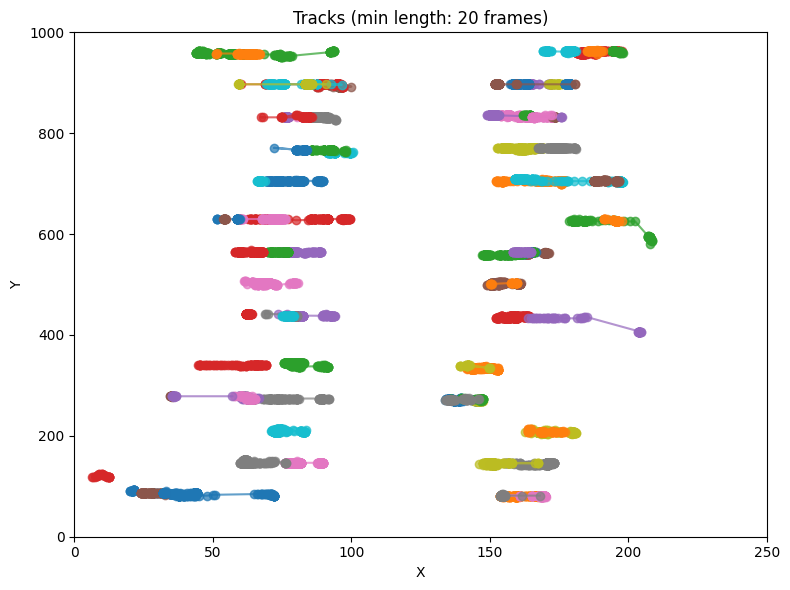

In [ ]:
#@title Plot Btracks
import matplotlib.pyplot as plt
import pandas as pd

def plot_btrack_tracks(df, target_track_id=None, highlight_only=False, min_length=0):
    # Ensure correct types
    df['track_id'] = df['track_id'].astype(int)
    df['frame'] = df['frame'].astype(int)

    # Filter out short tracks
    valid_track_ids = (
        df.groupby('track_id')['frame'].nunique()
        .loc[lambda x: x >= min_length]
        .index
    )
    df_filtered = df[df['track_id'].isin(valid_track_ids)]

    if df_filtered.empty:
        print(f"No tracks found with length ≥ {min_length} frames.")
        return

    fig, ax = plt.subplots(figsize=(8, 6))

    if target_track_id is not None:
        if not highlight_only:
            for tid, group in df_filtered.groupby('track_id'):
                if tid != target_track_id:
                    ax.plot(group['x'], group['y'], color='gray', alpha=0.4, linewidth=1)

        target_group = df_filtered[df_filtered['track_id'] == target_track_id]
        if not target_group.empty:
            ax.plot(target_group['x'], target_group['y'], color='red', linewidth=2.5, marker='o', label=f'Track {target_track_id}')
            ax.legend()
        else:
            print(f"Track {target_track_id} not found or does not meet min_length={min_length}.")
    else:
        for tid, group in df_filtered.groupby('track_id'):
            ax.plot(group['x'], group['y'], marker='o', alpha=0.7, label=f'Track {tid}')
        # ax.legend(loc='best', fontsize='small')

    ax.set_xlabel('X')
    #ax.set_xticklabels([])
    ax.set_ylabel('Y')
    #ax.set_yticklabels([])
    ax.set_title(f'Tracks (min length: {min_length} frames)')
    ax.set_xlim(0, 250)
    ax.set_ylim(0, 1000)
    plt.tight_layout()
    plt.show()

df = pd.read_csv('/content/tracked_objects.csv')
plot_btrack_tracks(df, target_track_id=TRACK_ID, highlight_only=ALONE, min_length= MIN_LENGTH)

In [ ]:
#@title Customize plot
METRIC='area' # 'area' or 'perimeter'

# Below variables will change based on the expirimental video

X_RANGE=(0, 400) # (0,300) for the full width
Y_RANGE=(0, 2000) # (0,1100) for the full height
MIN_TRACK_DURACTION=337 # 337 for full length
MAX_TRACKS=5

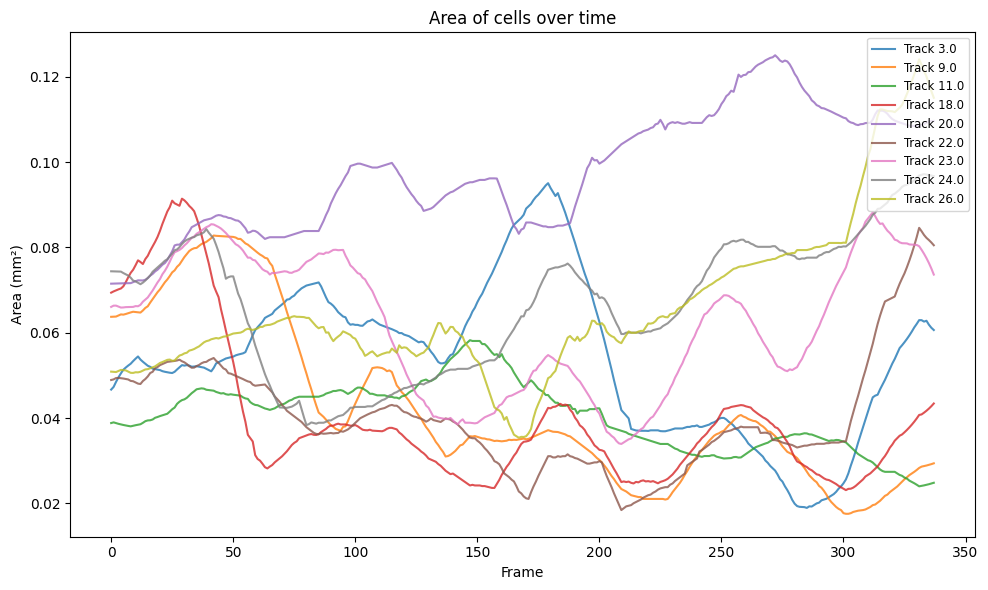

In [ ]:
#@title Plot ____ over time

def plot_area_over_time(
    df_area,
    df_location,
    metric='area',
    min_track_duration=5,
    max_tracks=None,
    smoothing_window=3,
    x_range=None,  # (x_min, x_max)
    y_range=None   # (y_min, y_max)
):
    import matplotlib.pyplot as plt
    import pandas as pd

    # Merge on track_id and frame
    df_merged = pd.merge(df_area, df_location, on=['track_id', 'frame'], how='inner')

    # Filter by spatial region if specified
    if x_range is not None:
        x_min, x_max = x_range
        df_merged = df_merged[(df_merged['x'] >= x_min) & (df_merged['x'] <= x_max)]

    if y_range is not None:
        y_min, y_max = y_range
        df_merged = df_merged[(df_merged['y'] >= y_min) & (df_merged['y'] <= y_max)]

    fig, ax = plt.subplots(figsize=(10, 6))
    shown = 0

    pixel_size_mm = 0.033
    area_conversion_factor = pixel_size_mm ** 2

    for track_id, group in df_merged.groupby('track_id'):
        frame_span = group['frame'].nunique()
        if frame_span < min_track_duration:
            continue

        group_sorted = group.sort_values('frame')
        smoothed = group_sorted[metric].rolling(window=smoothing_window, center=True, min_periods=1).mean()
        smoothed_mm2 = smoothed * area_conversion_factor
        ax.plot(group_sorted['frame'], smoothed_mm2, label=f'Track {track_id}', alpha=0.8)

        shown += 1
        if max_tracks is not None and shown >= max_tracks:
            break

    ax.set_xlabel('Frame')
    ax.set_ylabel(f'{metric.capitalize()} (mm²)')
    ax.set_title(f'{metric.capitalize()} of cells over time')
    if shown > 0:
        ax.legend(fontsize='small', loc='upper right')
    else:
        ax.text(0.5, 0.5, 'No tracks in specified region', transform=ax.transAxes, ha='center', va='center')
    plt.tight_layout()
    plt.show()

# Plot
df_area = pd.read_csv('/content/area_perimeter_over_time.csv')
df_location = pd.read_csv('/content/tracked_objects.csv')
plot_area_over_time(
    df_area, df_location,
    metric= METRIC,
    x_range=X_RANGE,
    y_range=Y_RANGE,
    min_track_duration=MIN_TRACK_DURACTION,
    max_tracks=MAX_TRACKS,
    smoothing_window=30
)

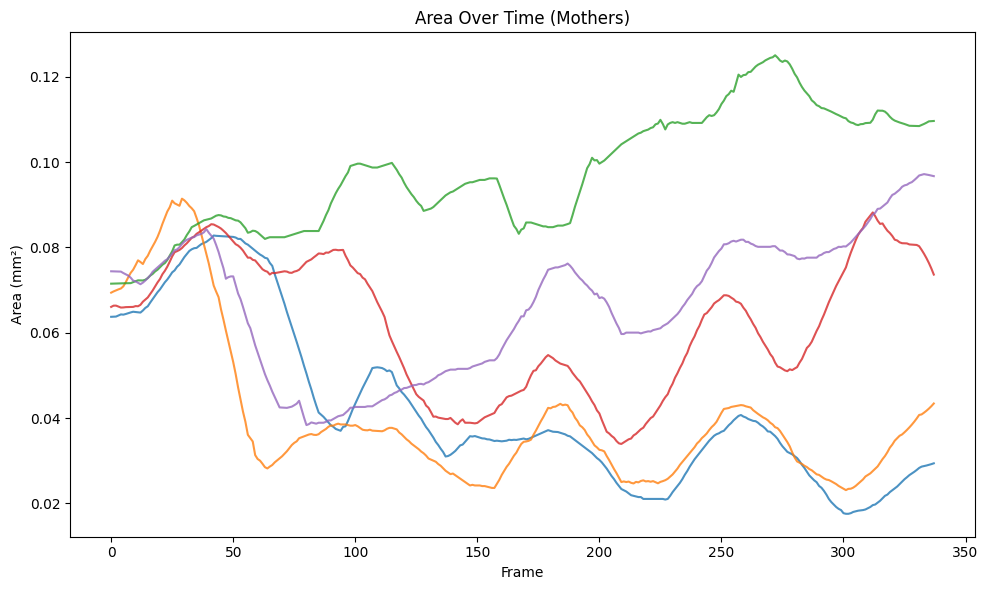

In [ ]:
#@title Plotting tool to select tracks
def plot_area_over_time(
    df_area,
    df_location,
    metric='area',
    min_track_duration=5,
    max_tracks=None,
    smoothing_window=3,
    x_range=None,
    y_range=None,
    fps=None,
    time_unit='frame',
    track_ids=None,
    pixel_size_mm=None
):
    import matplotlib.pyplot as plt
    import pandas as pd

    # Merge area and location data on track_id and frame
    df_merged = pd.merge(df_area, df_location, on=['track_id', 'frame'], how='inner')

    # Filter by selected track_ids
    if track_ids is not None:
        df_merged = df_merged[df_merged['track_id'].isin(track_ids)]
        missing = set(track_ids) - set(df_merged['track_id'].unique())
        if missing:
            print(f"Warning: These track_ids were not found and will be skipped: {missing}")

    # Filter by spatial region if provided
    if x_range is not None:
        x_min, x_max = x_range
        df_merged = df_merged[(df_merged['x'] >= x_min) & (df_merged['x'] <= x_max)]

    if y_range is not None:
        y_min, y_max = y_range
        df_merged = df_merged[(df_merged['y'] >= y_min) & (df_merged['y'] <= y_max)]

    fig, ax = plt.subplots(figsize=(10, 6))
    shown = 0

    for track_id, group in df_merged.groupby('track_id'):
        frame_span = group['frame'].nunique()
        if frame_span < min_track_duration:
            continue

        group_sorted = group.sort_values('frame')

        # Time conversion for x-axis
        if fps and time_unit == 'seconds':
            x_vals = group_sorted['frame'] / fps
            xlabel = "Time (s)"
        elif fps and time_unit == 'minutes':
            x_vals = group_sorted['frame'] / (fps * 60)
            xlabel = "Time (min)"
        else:
            x_vals = group_sorted['frame']
            xlabel = "Frame"

        # Area conversion for y-axis
        smoothed = group_sorted[metric].rolling(window=smoothing_window, center=True, min_periods=1).mean()
        if pixel_size_mm:
            smoothed = smoothed * (pixel_size_mm ** 2)
            ylabel = f"{metric.capitalize()} (mm²)"
        else:
            ylabel = f"{metric.capitalize()} (px²)"

        # Plot the line
        ax.plot(x_vals, smoothed, label=f'Track {track_id}', alpha=0.8)

        shown += 1
        if max_tracks is not None and shown >= max_tracks:
            break

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{metric.capitalize()} Over Time (Mothers)')

    if shown > 0:
        #ax.legend(fontsize='small', loc='upper right')
        print('')
    else:
        ax.text(0.5, 0.5, 'No tracks to display', transform=ax.transAxes, ha='center', va='center')

    plt.tight_layout()
    plt.show()


plot_area_over_time(
    df_area,
    df_location,
    track_ids=[24, 9, 18,23,20],
    time_unit='Frames',
    pixel_size_mm=0.033,
    min_track_duration=0,
    max_tracks=200,
    smoothing_window=30,
)


   parent_id  child_id
0       95.0      97.0
1      126.0     128.0
2      204.0     239.0
3      204.0     247.0
4      222.0     289.0
5      222.0     291.0


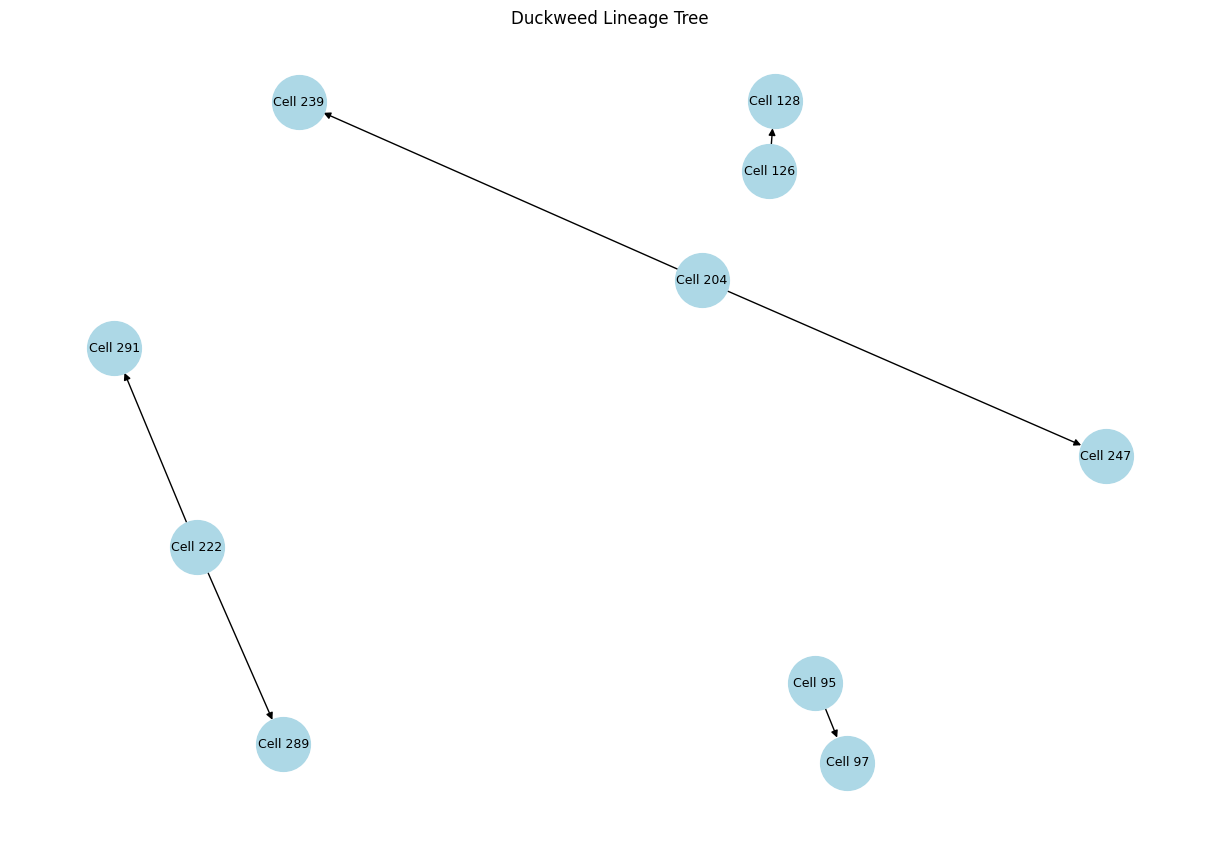

In [ ]:
#@title Expiriemnting with lineage -- need to fix btrack version issue
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

def infer_lineage(track_df, max_frame_gap=2, max_dist=20):

    # Find track start and end frames & positions
    track_groups = track_df.groupby('track_id')
    track_info = track_groups.agg(
        start_frame=('frame', 'min'),
        end_frame=('frame', 'max'),
        start_x=('x', lambda x: x.iloc[0]),
        start_y=('y', lambda x: x.iloc[0]),
        end_x=('x', lambda x: x.iloc[-1]),
        end_y=('y', lambda x: x.iloc[-1])
    ).reset_index()

    # Create separate DataFrames for track starts and ends
    starts = track_info[['track_id', 'start_frame', 'start_x', 'start_y']].copy()
    ends = track_info[['track_id', 'end_frame', 'end_x', 'end_y']].copy()

    # For quick lookup, build KD-trees per frame for starts
    lineage_pairs = []

    # Index starts by frame
    starts_by_frame = starts.groupby('start_frame')

    # For each ending track, find candidate children starting shortly after end frame
    for idx, parent in ends.iterrows():
        parent_id = parent['track_id']
        parent_end_frame = int(parent['end_frame'])
        parent_pos = np.array([parent['end_x'], parent['end_y']])

        candidate_frames = list(range(parent_end_frame + 1, parent_end_frame + max_frame_gap + 1))

        candidate_dfs = [starts_by_frame.get_group(f) for f in candidate_frames if f in starts_by_frame.groups]

        if len(candidate_dfs) == 0:
            continue

        candidates = pd.concat(candidate_dfs, ignore_index=True)

        tree = cKDTree(candidates[['start_x', 'start_y']].values)
        idxs = tree.query_ball_point(parent_pos, max_dist)

        for i in idxs:
            child_id = candidates.iloc[i]['track_id']
            lineage_pairs.append({'parent_id': parent_id, 'child_id': child_id})

    lineage_df = pd.DataFrame(lineage_pairs).drop_duplicates()
    return lineage_df
import networkx as nx
import matplotlib.pyplot as plt

def draw_lineage_tree(lineage_df):
    G = nx.DiGraph()

    # Add edges from parent to child
    for _, row in lineage_df.iterrows():
        parent = f"Cell {int(row['parent_id'])}"
        child = f"Cell {int(row['child_id'])}"
        G.add_edge(parent, child)

    # Try hierarchical layout (requires pygraphviz)
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog='dot')
    except:
        pos = nx.spring_layout(G)  # fallback layout

    plt.figure(figsize=(12, 8))
    nx.draw(G, pos, with_labels=True, arrows=True, node_size=1500, node_color='lightblue', font_size=9)
    plt.title("Duckweed Lineage Tree")
    plt.show()

lineage_df = infer_lineage(track_df, max_frame_gap=2, max_dist=20)
print(lineage_df)
draw_lineage_tree(lineage_df)
